In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('mushroom.csv')

In [4]:
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [5]:
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [6]:
numeric_df = df.select_dtypes(include='number')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (numeric_df < lower) | (numeric_df > upper)
print(outliers.sum())

Unnamed: 0      0
stalk_height    0
cap_diameter    0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [8]:
df.size

52000

In [9]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


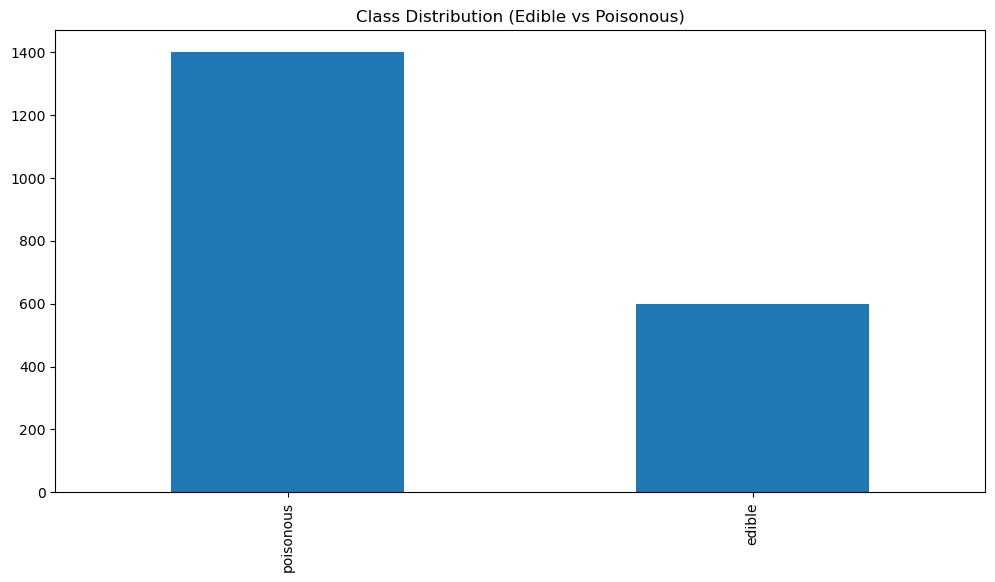

In [10]:
plt.figure(figsize=(12,6))
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Edible vs Poisonous)")
plt.show()


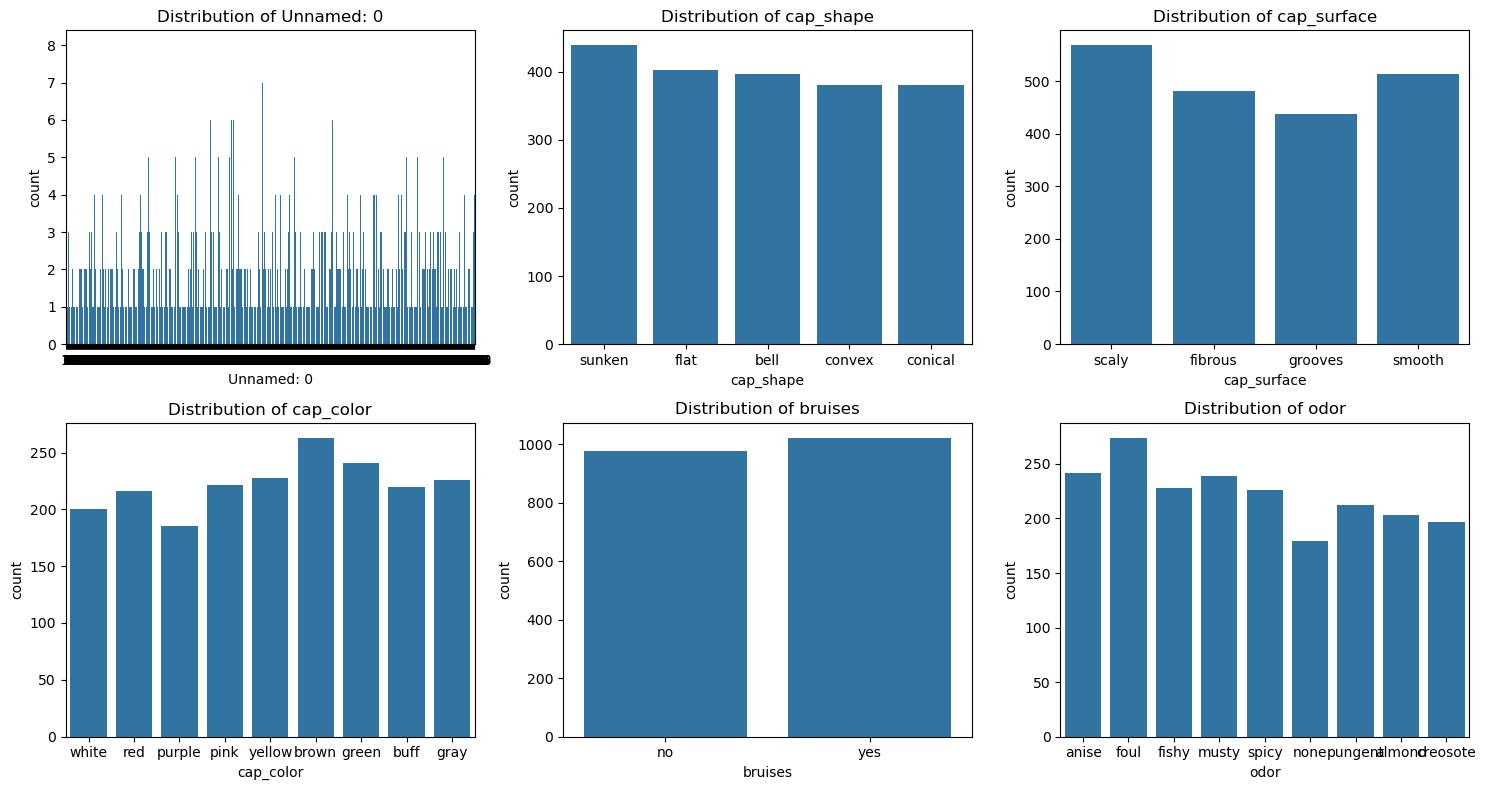

In [11]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
cols = df.columns[:6]

for col, ax in zip(cols, axes.flatten()):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
df_encoded = df.apply(LabelEncoder().fit_transform)

X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]


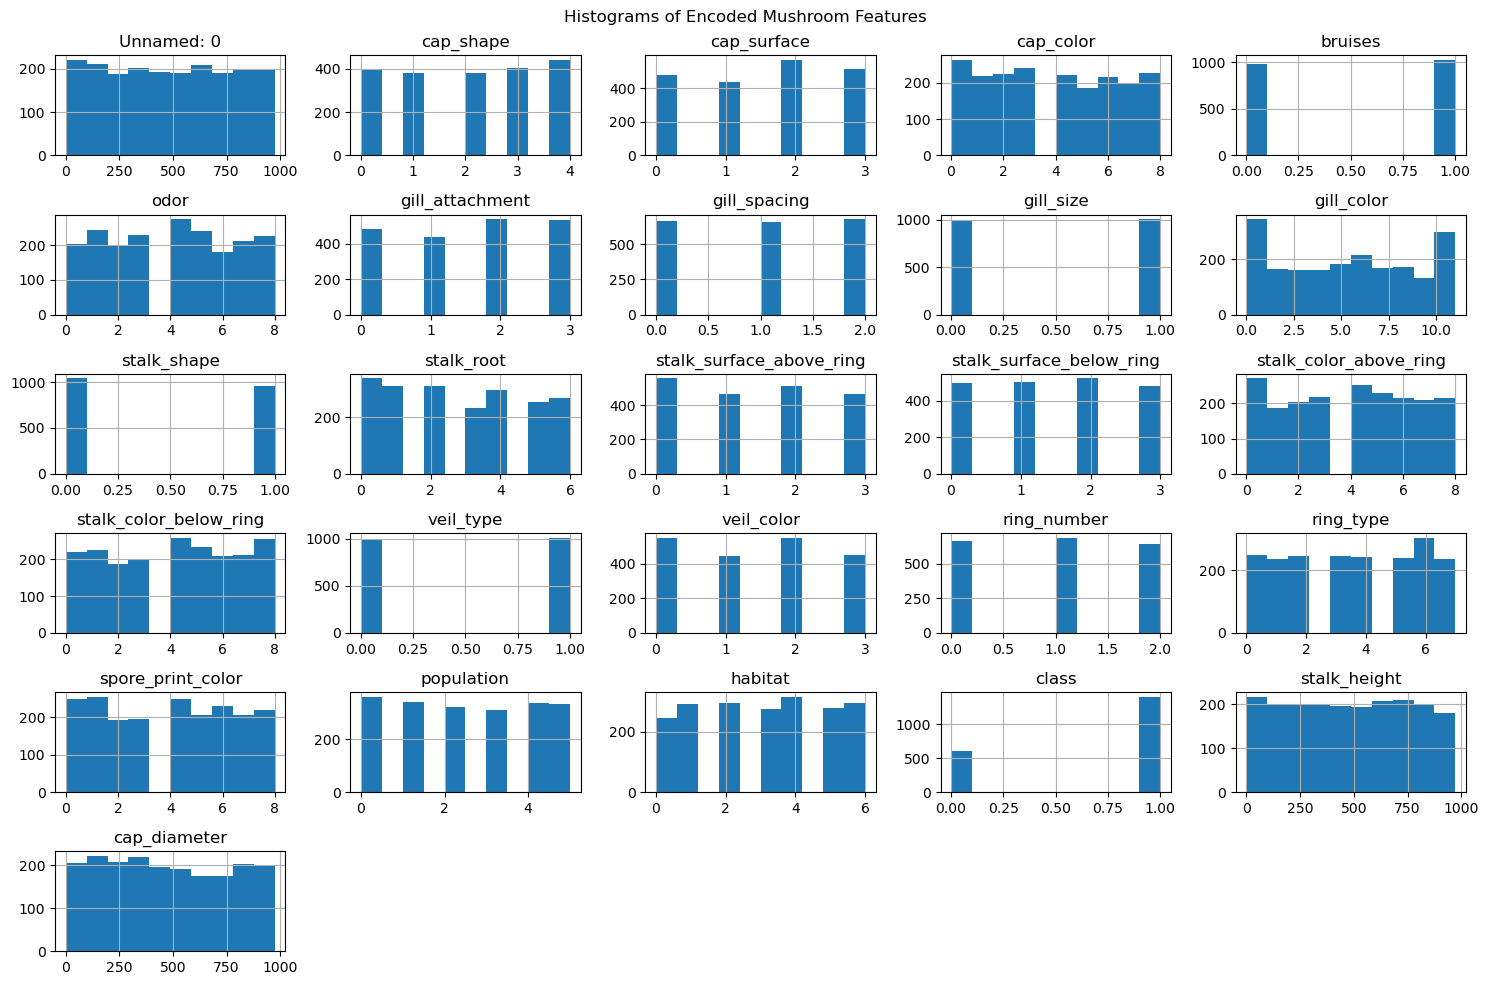

In [14]:
df_encoded.hist(figsize=(15, 10), bins=10)
plt.suptitle("Histograms of Encoded Mushroom Features", fontsize=12)
plt.tight_layout()
plt.show()


<Figure size 1500x800 with 0 Axes>

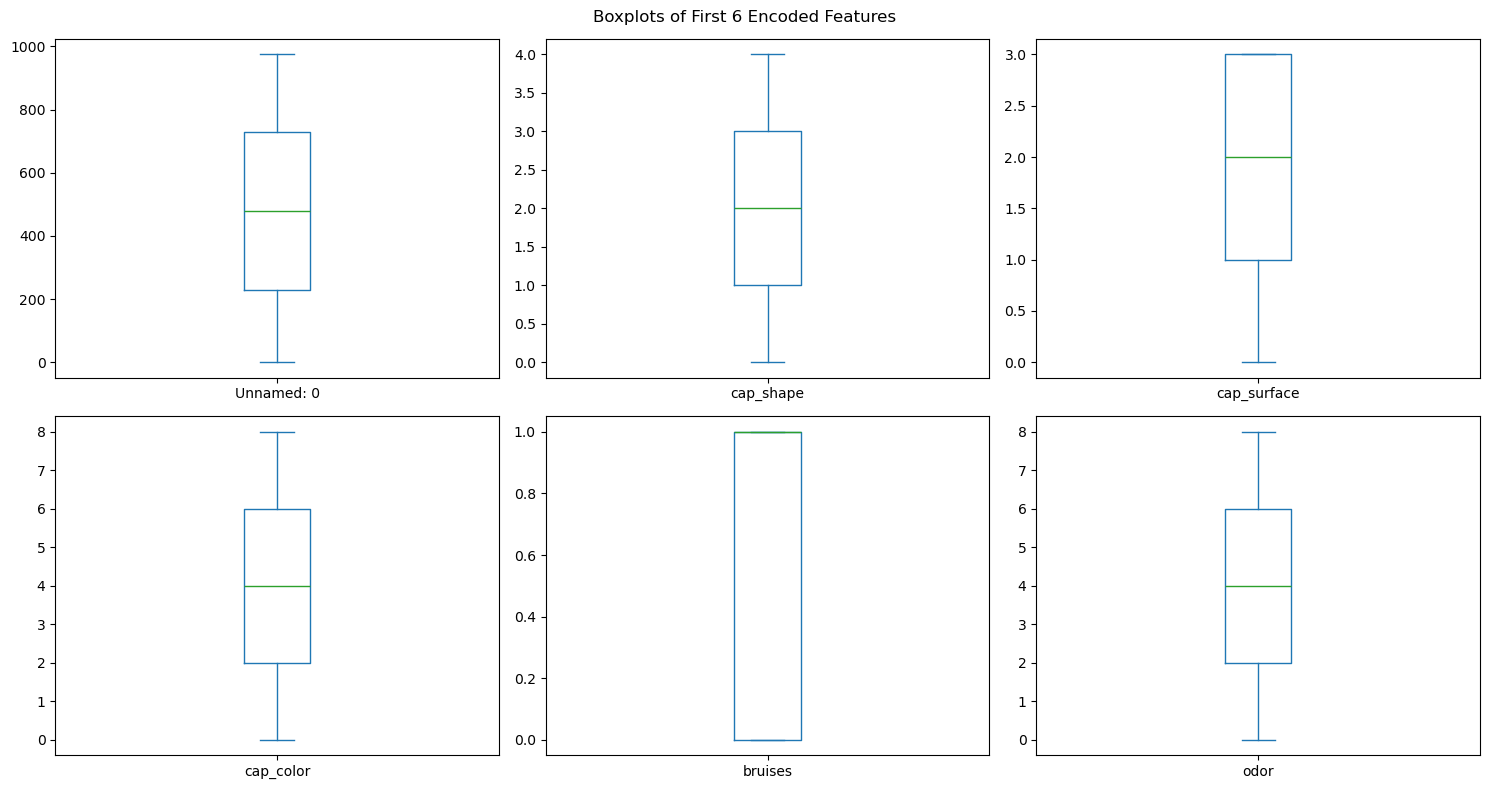

In [15]:
plt.figure(figsize=(15, 8))
df_encoded.iloc[:, :6].plot(kind='box', subplots=True, layout=(2,3), figsize=(15,8))
plt.suptitle("Boxplots of First 6 Encoded Features")
plt.tight_layout()
plt.show()


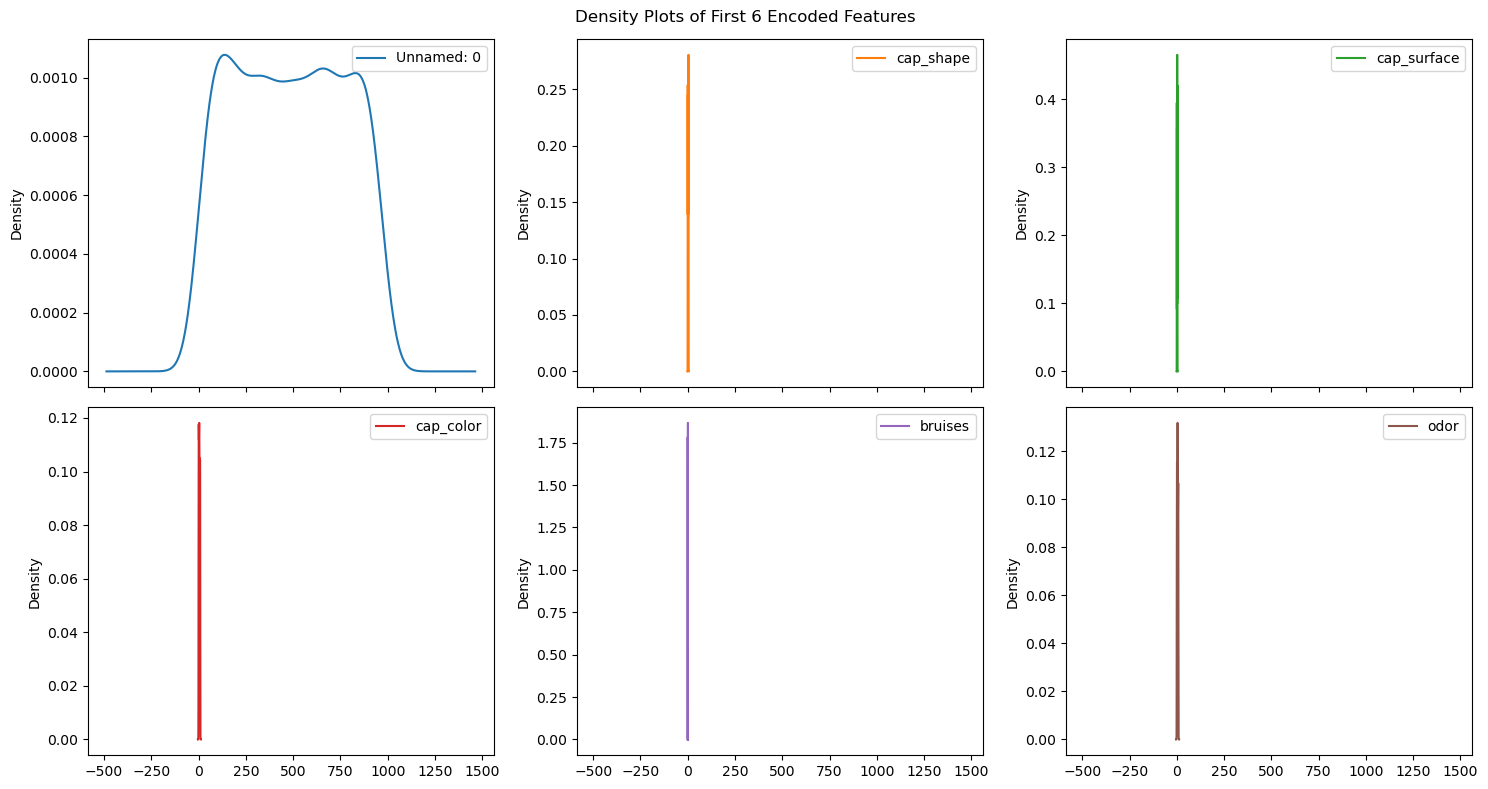

In [16]:
df_encoded.iloc[:, :6].plot(kind='density', subplots=True, layout=(2,3), figsize=(15,8))
plt.suptitle("Density Plots of First 6 Encoded Features")
plt.tight_layout()
plt.show()


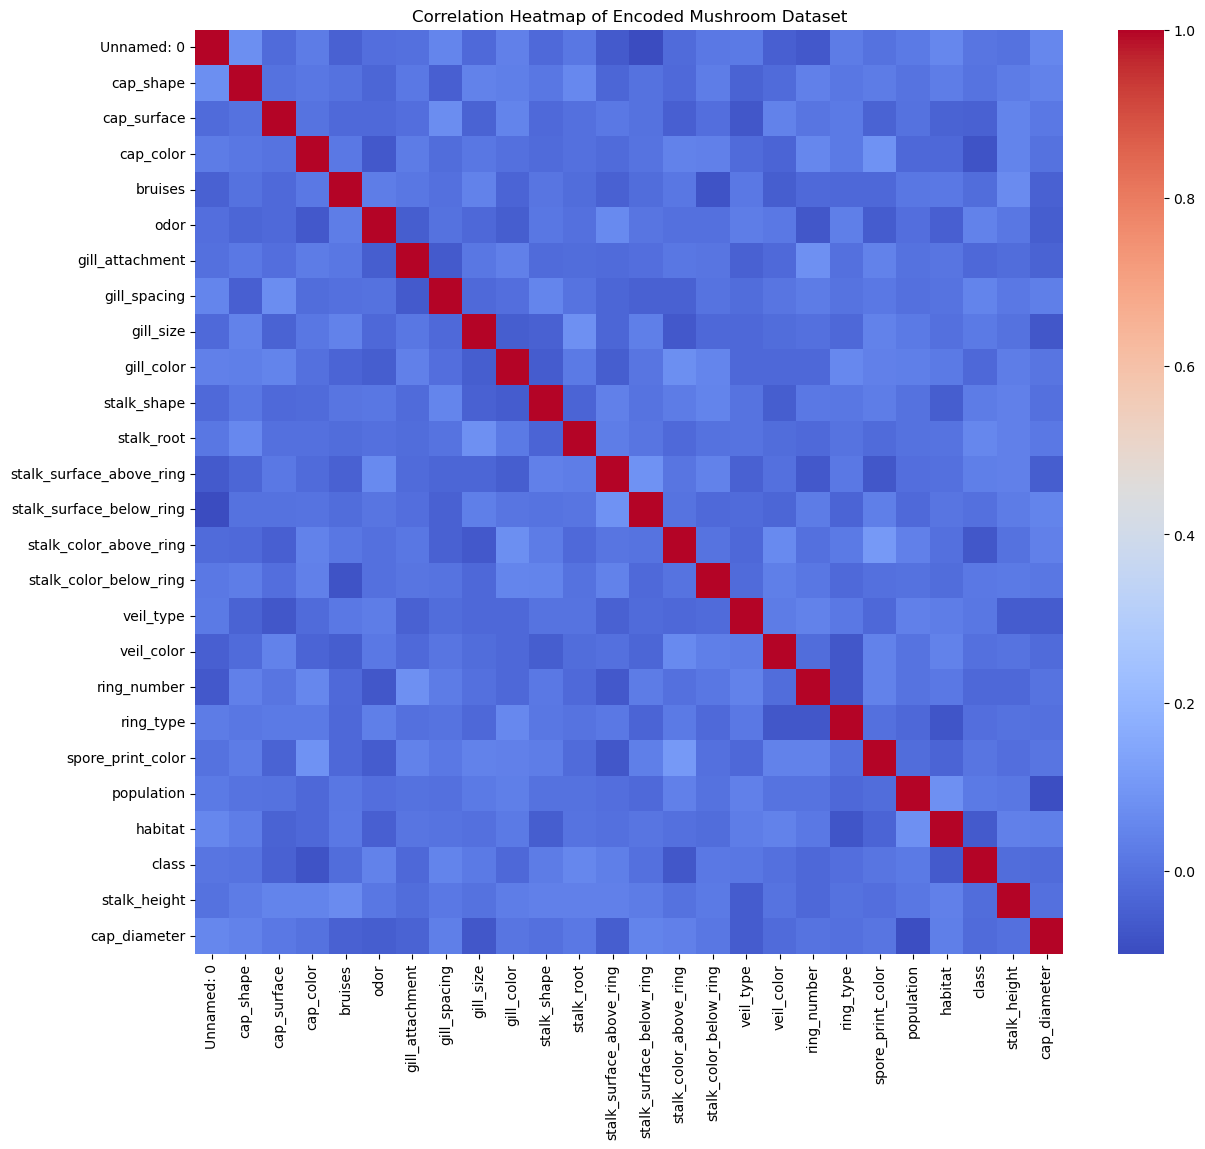

In [17]:
plt.figure(figsize=(14, 12))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Encoded Mushroom Dataset")
plt.show()


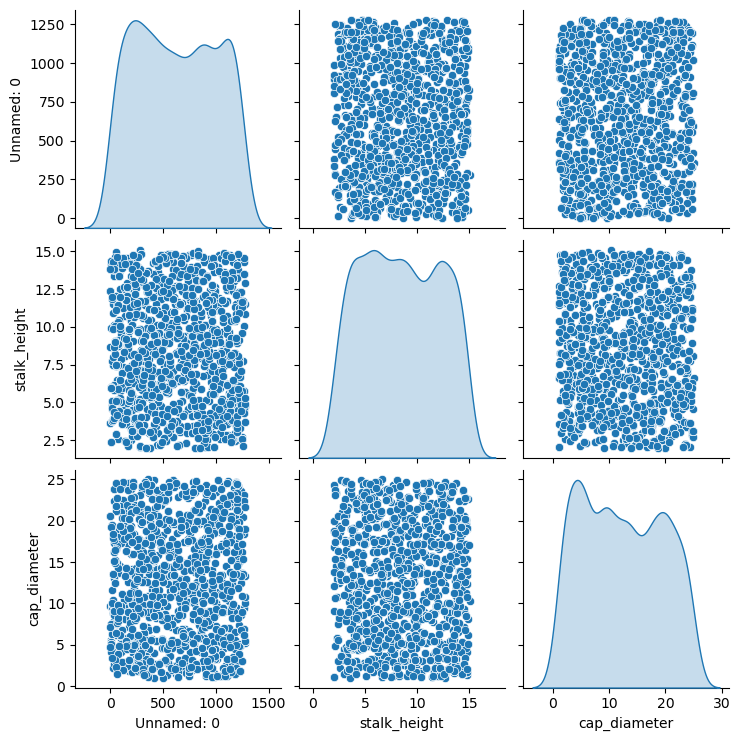

In [18]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
sns.pairplot(df[numeric_features], diag_kind='kde')  
plt.show()


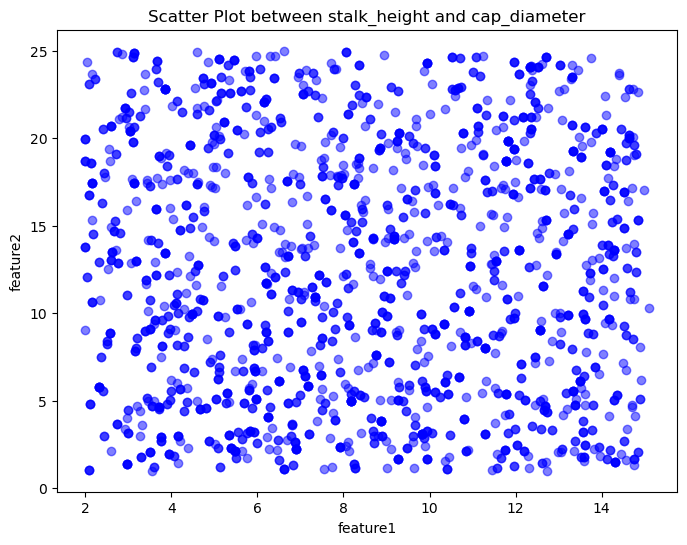

In [19]:
import matplotlib.pyplot as plt

# Suppose df is your DataFrame and 'feature1' and 'feature2' are numeric features
plt.figure(figsize=(8,6))
plt.scatter(df['stalk_height'], df['cap_diameter'], c='blue', alpha=0.5)
plt.title('Scatter Plot between stalk_height and cap_diameter')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()


In [20]:
df_encoded.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,889,4,2,7,0,1,1,2,0,7,...,0,0,2,6,3,1,5,1,916,190
1,786,4,0,6,0,1,3,1,1,3,...,1,0,2,6,1,2,5,0,128,750
2,246,3,1,5,1,4,1,1,0,8,...,1,3,2,6,6,0,5,1,537,281
3,221,0,2,4,1,3,3,0,0,6,...,0,3,2,0,4,1,0,1,234,829
4,630,3,3,8,1,5,2,1,1,6,...,1,2,0,4,8,1,4,1,895,484


In [21]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler

In [22]:
X = df_encoded.drop(columns=['class'])   # numeric features only
y = df_encoded['class']


In [23]:
X

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,stalk_height,cap_diameter
0,889,4,2,7,0,1,1,2,0,7,...,8,0,0,2,6,3,1,5,916,190
1,786,4,0,6,0,1,3,1,1,3,...,0,1,0,2,6,1,2,5,128,750
2,246,3,1,5,1,4,1,1,0,8,...,3,1,3,2,6,6,0,5,537,281
3,221,0,2,4,1,3,3,0,0,6,...,5,0,3,2,0,4,1,0,234,829
4,630,3,3,8,1,5,2,1,1,6,...,7,1,2,0,4,8,1,4,895,484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,656,4,2,0,1,4,0,1,1,3,...,4,0,1,1,2,6,0,1,283,680
1996,885,4,2,5,1,5,0,2,1,9,...,4,0,2,1,7,8,2,5,335,521
1997,205,2,1,3,1,3,3,0,1,7,...,6,0,0,2,1,8,0,6,859,438
1998,329,0,3,7,0,7,2,0,1,6,...,5,1,3,1,0,1,5,6,679,320


In [24]:
y

0       1
1       0
2       1
3       1
4       1
       ..
1995    1
1996    1
1997    1
1998    1
1999    1
Name: class, Length: 2000, dtype: int32

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [27]:
svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)


In [28]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))




Accuracy: 0.6675
Precision: 0.6675
Recall: 1.0
F1-score: 0.800599700149925


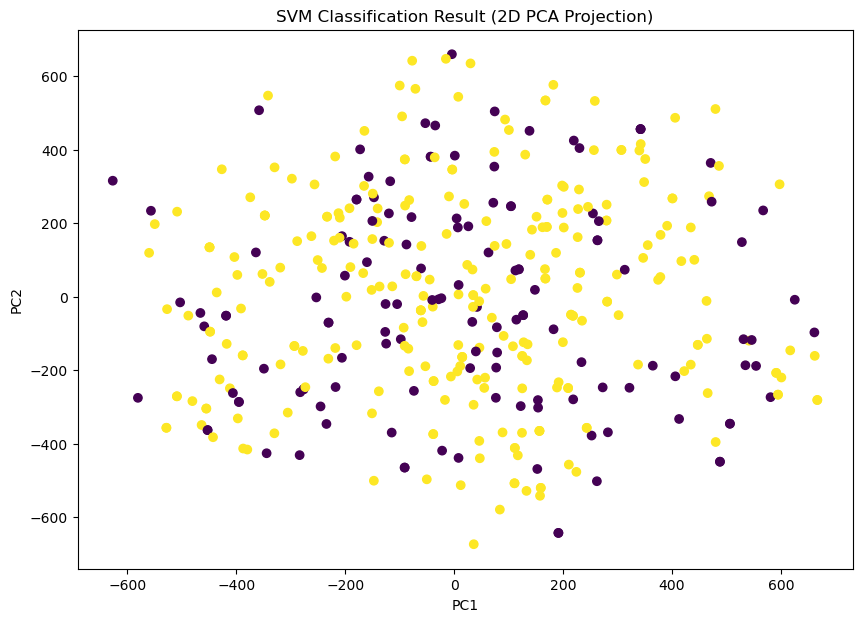

In [29]:
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2)
X_train_2D = pca_2d.fit_transform(X_train)
X_test_2D = pca_2d.transform(X_test)

svm_2d = SVC(kernel='rbf')
svm_2d.fit(X_train_2D, y_train)

# Plot
plt.figure(figsize=(10,7))
plt.scatter(X_test_2D[:,0], X_test_2D[:,1], c=y_test, cmap='viridis')
plt.title("SVM Classification Result (2D PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [30]:
params = {
    'kernel': ['linear','poly','rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale','auto']
}

grid = GridSearchCV(SVC(), params, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Best Accuracy: 0.8481249999999999


In [31]:
kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)

    print(f"\n===== Kernel: {k.upper()} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred_k))
    print("Precision:", precision_score(y_test, y_pred_k))
    print("Recall:", recall_score(y_test, y_pred_k))
    print("F1-score:", f1_score(y_test, y_pred_k))



===== Kernel: LINEAR =====
Accuracy: 0.6675
Precision: 0.6675
Recall: 1.0
F1-score: 0.800599700149925

===== Kernel: POLY =====
Accuracy: 0.83
Precision: 0.8119122257053292
Recall: 0.9700374531835206
F1-score: 0.8839590443686007

===== Kernel: RBF =====
Accuracy: 0.7875
Precision: 0.7614942528735632
Recall: 0.9925093632958801
F1-score: 0.8617886178861789
